In [54]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [55]:
base_path = "/content/drive/MyDrive/Olist_Ecommerce_Project/data/"

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [57]:
customers = pd.read_csv(base_path + "olist_customers_dataset.csv")
orders = pd.read_csv(base_path + "olist_orders_dataset.csv")

In [58]:
order_items = pd.read_csv(base_path + "olist_order_items_dataset.csv")
payments = pd.read_csv(base_path + "olist_order_payments_dataset.csv")
reviews = pd.read_csv(base_path + "olist_order_reviews_dataset.csv")
products = pd.read_csv(base_path + "olist_products_dataset.csv")
sellers = pd.read_csv(base_path + "olist_sellers_dataset.csv")
category_translation = pd.read_csv(
    base_path + "product_category_name_translation.csv"
)

In [59]:
datasets = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "payments": payments,
    "reviews": reviews,
    "products": products,
    "sellers": sellers,
    "category_translation": category_translation
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

customers: (99441, 5)
orders: (99441, 8)
order_items: (112650, 7)
payments: (103886, 5)
reviews: (99224, 7)
products: (32951, 9)
sellers: (3095, 4)
category_translation: (71, 2)


In [60]:
for name, df in datasets.items():
    print(f"\n{name}")
    print(df.isnull().sum())


customers
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

orders
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

order_items
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

payments
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

reviews
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review

In [61]:
print("Duplicate rows:")
for name, df in datasets.items():
    print(name, df.duplicated().sum())

Duplicate rows:
customers 0
orders 0
order_items 0
payments 0
reviews 0
products 0
sellers 0
category_translation 0


In [62]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

In [63]:
print(orders.dtypes)
print()
print(reviews.dtypes)

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

review_id                  object
order_id                   object
review_score                int64
review_comment_title       object
review_comment_message     object
review_creation_date       object
review_answer_timestamp    object
dtype: object


In [64]:
orders["delivery_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_purchase_timestamp"]
).dt.total_seconds() / 86400

In [65]:
orders["valid_delivery_days"] = orders["delivery_days"].where(
    orders["delivery_days"] >= 0
)

In [66]:
# Start with an empty text column
orders["delivery_status"] = pd.Series(
    pd.NA,
    index=orders.index,
    dtype="object"
)

# Only evaluate orders that have both actual and estimated delivery dates
valid_delivery_date = (
    orders["order_delivered_customer_date"].notna()
    & orders["order_estimated_delivery_date"].notna()
)

# Compare calendar dates, following our final SQL definition
orders.loc[valid_delivery_date, "delivery_status"] = np.where(
    orders.loc[
        valid_delivery_date,
        "order_delivered_customer_date"
    ].dt.normalize()
    <=
    orders.loc[
        valid_delivery_date,
        "order_estimated_delivery_date"
    ].dt.normalize(),
    "On Time",
    "Late"
)

In [67]:
orders["carrier_before_purchase"] = (
    orders["order_delivered_carrier_date"].notna()
    & (
        orders["order_delivered_carrier_date"]
        < orders["order_purchase_timestamp"]
    )
)

In [68]:
print(
    "Carrier-before-purchase anomalies:",
    orders["carrier_before_purchase"].sum()
)

Carrier-before-purchase anomalies: 166


In [69]:
delivered = orders[
    (orders["order_status"] == "delivered")
    & orders["order_delivered_customer_date"].notna()
].copy()

print("Valid delivered orders:", delivered["valid_delivery_days"].notna().sum())

print(
    "Average delivery days:",
    round(delivered["valid_delivery_days"].mean(), 2)
)

print(
    "Fastest delivery:",
    round(delivered["valid_delivery_days"].min(), 2)
)

print(
    "Slowest delivery:",
    round(delivered["valid_delivery_days"].max(), 2)
)

print("\nDelivery status:")
print(delivered["delivery_status"].value_counts())

print("\nDelivery percentage:")
print(
    delivered["delivery_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Valid delivered orders: 96470
Average delivery days: 12.56
Fastest delivery: 0.53
Slowest delivery: 209.63

Delivery status:
delivery_status
On Time    89936
Late        6534
Name: count, dtype: int64

Delivery percentage:
delivery_status
On Time   93.23
Late       6.77
Name: proportion, dtype: float64


Monthly Sales and Revenue Trends

In [70]:
delivered_orders = orders[
    orders["order_status"] == "delivered"
].copy()

sales = delivered_orders.merge(
    order_items,
    on="order_id",
    how="inner"
)

In [71]:
sales["purchase_month"] = (
    sales["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

In [72]:
monthly_sales = (
    sales.groupby("purchase_month")
    .agg(
        orders=("order_id", "nunique"),
        products_sold=("order_item_id", "count"),
        revenue=("price", "sum")
    )
    .reset_index()
)

monthly_sales["average_order_value"] = (
    monthly_sales["revenue"] /
    monthly_sales["orders"]
)

monthly_sales

,purchase_month,orders,products_sold,revenue,average_order_value
0,2016-09,1,3,134.97,134.97
1,2016-10,265,313,"40,325.11",152.17
2,2016-12,1,1,10.90,10.90
3,2017-01,750,913,"111,798.36",149.06
4,2017-02,1653,1858,"234,223.40",141.70
5,2017-03,2546,2897,"359,198.85",141.08
6,2017-04,2303,2569,"340,669.68",147.92
7,2017-05,3546,4004,"489,338.25",138.00
8,2017-06,3135,3489,"421,923.37",134.58
9,2017-07,3872,4416,"481,604.52",124.38


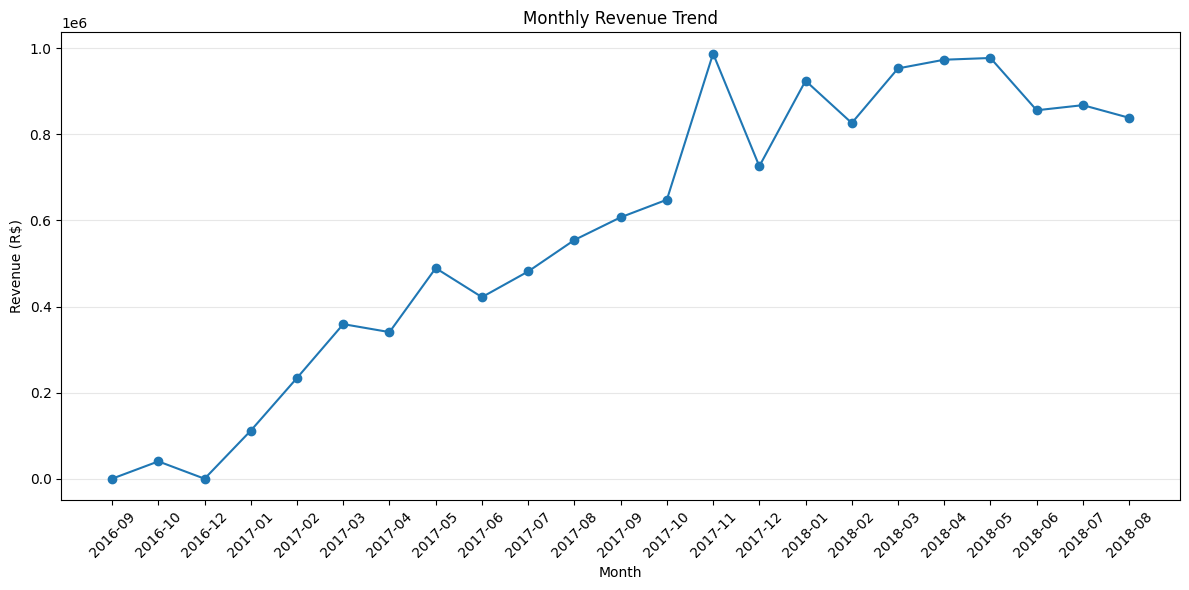

In [73]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales["purchase_month"],
    monthly_sales["revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (R$)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

Product Category Sales Performance

In [74]:
category_sales_data = (
    sales
    .merge(
        products[
            ["product_id", "product_category_name"]
        ],
        on="product_id",
        how="left"
    )
    .merge(
        category_translation,
        on="product_category_name",
        how="left"
    )
)

In [75]:
category_sales_data["category"] = (
    category_sales_data["product_category_name_english"]
    .fillna(category_sales_data["product_category_name"])
    .fillna("Unknown")
)

In [76]:
category_sales = (
    category_sales_data
    .groupby("category")
    .agg(
        orders=("order_id", "nunique"),
        products_sold=("order_item_id", "count"),
        revenue=("price", "sum"),
        avg_product_price=("price", "mean")
    )
    .reset_index()
)

category_sales["revenue_percentage"] = (
    category_sales["revenue"]
    / category_sales["revenue"].sum()
    * 100
)

category_sales = category_sales.sort_values(
    "revenue",
    ascending=False
)

category_sales.head(15)

,category,orders,products_sold,revenue,avg_product_price,revenue_percentage
44,health_beauty,8647,9465,"1,233,131.72",130.28,9.33
73,watches_gifts,5495,5859,"1,166,176.98",199.04,8.82
8,bed_bath_table,9272,10953,"1,023,434.76",93.44,7.74
68,sports_leisure,7530,8431,"954,852.55",113.25,7.22
16,computers_accessories,6530,7644,"888,724.61",116.26,6.72
40,furniture_decor,6307,8160,"711,927.69",87.25,5.38
50,housewares,5743,6795,"615,628.69",90.60,4.66
21,cool_stuff,3559,3718,"610,204.10",164.12,4.62
6,auto,3810,4140,"578,966.65",139.85,4.38
72,toys,3804,4030,"471,286.48",116.94,3.56


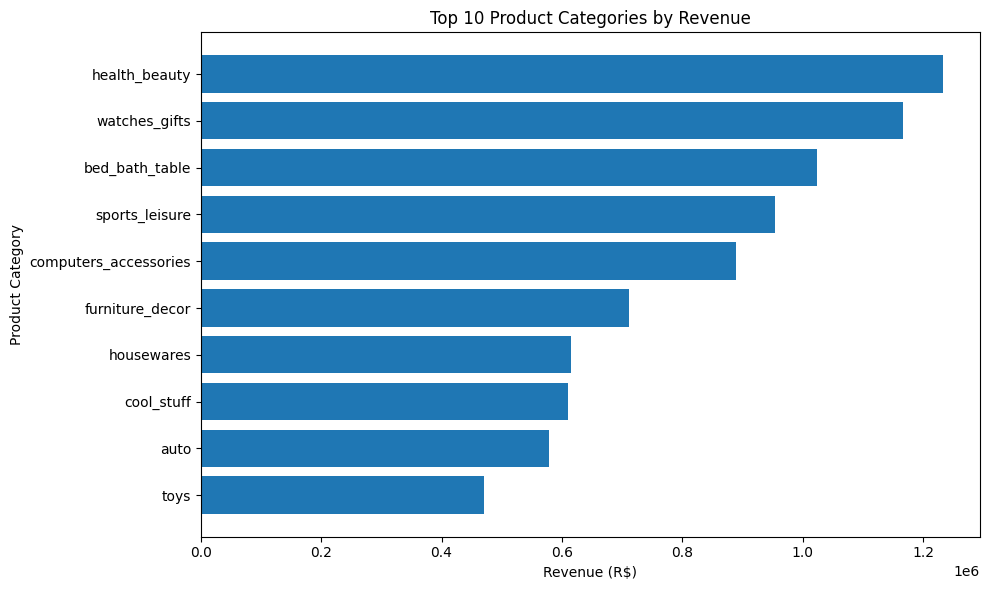

In [77]:
top_categories = (
    category_sales
    .head(10)
    .sort_values("revenue")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_categories["category"],
    top_categories["revenue"]
)

plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Revenue (R$)")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()

Repeat Customers and Customer Spending

In [78]:
customer_sales = (
    delivered_orders
    .merge(
        customers[
            ["customer_id", "customer_unique_id", "customer_state"]
        ],
        on="customer_id",
        how="left"
    )
    .merge(
        order_items[
            ["order_id", "order_item_id", "price"]
        ],
        on="order_id",
        how="inner"
    )
)

In [79]:
customer_summary = (
    customer_sales
    .groupby("customer_unique_id")
    .agg(
        total_orders=("order_id", "nunique"),
        products_purchased=("order_item_id", "count"),
        total_spent=("price", "sum")
    )
    .reset_index()
)

In [80]:
customer_summary["customer_type"] = np.where(
    customer_summary["total_orders"] == 1,
    "One-time Customer",
    "Repeat Customer"
)

In [81]:
retention = (
    customer_summary["customer_type"]
    .value_counts()
    .rename_axis("customer_type")
    .reset_index(name="customers")
)

retention["customer_percentage"] = (
    retention["customers"]
    / retention["customers"].sum()
    * 100
)

retention

,customer_type,customers,customer_percentage
0,One-time Customer,90557,97.00
1,Repeat Customer,2801,3.00


In [82]:
customer_value = (
    customer_summary
    .groupby("customer_type")
    .agg(
        customers=("customer_unique_id", "count"),
        avg_spend_per_customer=("total_spent", "mean"),
        total_revenue=("total_spent", "sum")
    )
    .reset_index()
)

customer_value["revenue_percentage"] = (
    customer_value["total_revenue"]
    / customer_value["total_revenue"].sum()
    * 100
)

customer_value

,customer_type,customers,avg_spend_per_customer,total_revenue,revenue_percentage
0,One-time Customer,90557,137.96,"12,493,089.36",94.49
1,Repeat Customer,2801,260.05,"728,408.75",5.51


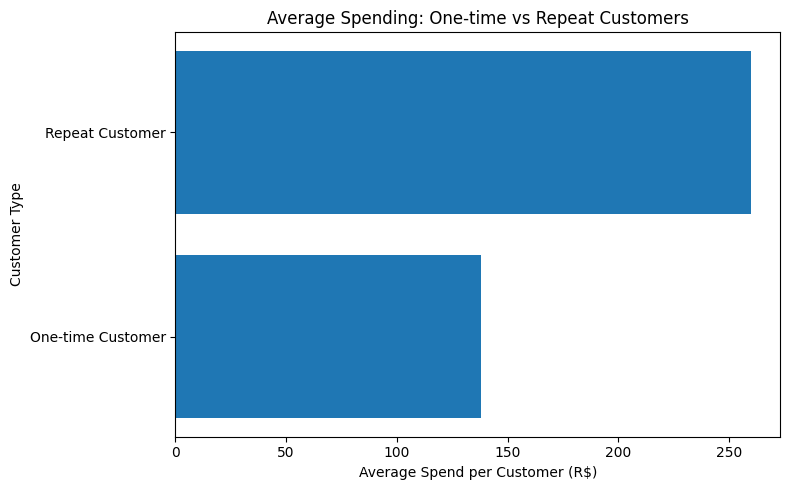

In [83]:
plot_data = customer_value.sort_values(
    "avg_spend_per_customer"
)

plt.figure(figsize=(8, 5))

plt.barh(
    plot_data["customer_type"],
    plot_data["avg_spend_per_customer"]
)

plt.title("Average Spending: One-time vs Repeat Customers")
plt.xlabel("Average Spend per Customer (R$)")
plt.ylabel("Customer Type")

plt.tight_layout()
plt.show()

Delivery Performance and Customer Satisfaction

In [84]:
delivery_reviews = (
    orders[
        (orders["order_status"] == "delivered")
        & orders["order_delivered_customer_date"].notna()
        & orders["order_estimated_delivery_date"].notna()
    ][["order_id", "delivery_status"]]
    .merge(
        reviews[["order_id", "review_score"]],
        on="order_id",
        how="inner"
    )
)

In [85]:
delivery_satisfaction = (
    delivery_reviews
    .groupby("delivery_status")
    .agg(
        reviews=("review_score", "count"),
        avg_review_score=("review_score", "mean"),
        positive_review_percentage=(
            "review_score",
            lambda x: (x >= 4).mean() * 100
        ),
        negative_review_percentage=(
            "review_score",
            lambda x: (x <= 2).mean() * 100
        )
    )
    .reset_index()
)

delivery_satisfaction[
    [
        "avg_review_score",
        "positive_review_percentage",
        "negative_review_percentage"
    ]
] = delivery_satisfaction[
    [
        "avg_review_score",
        "positive_review_percentage",
        "negative_review_percentage"
    ]
].round(2)

delivery_satisfaction

,delivery_status,reviews,avg_review_score,positive_review_percentage,negative_review_percentage
0,Late,6409,2.27,26.71,62.41
1,On Time,89944,4.29,82.64,9.28


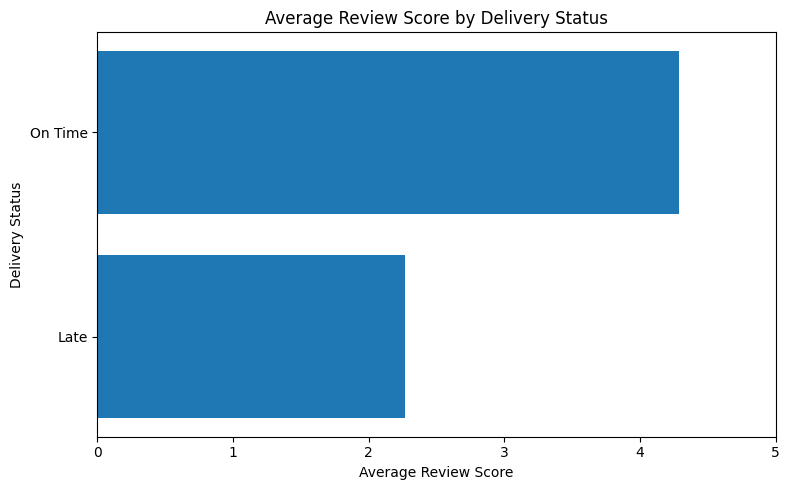

In [86]:
plot_data = (
    delivery_satisfaction
    .set_index("delivery_status")
    .loc[["Late", "On Time"]]
    .reset_index()
)

plt.figure(figsize=(8, 5))

plt.barh(
    plot_data["delivery_status"],
    plot_data["avg_review_score"]
)

plt.title("Average Review Score by Delivery Status")
plt.xlabel("Average Review Score")
plt.ylabel("Delivery Status")
plt.xlim(0, 5)

plt.tight_layout()
plt.show()

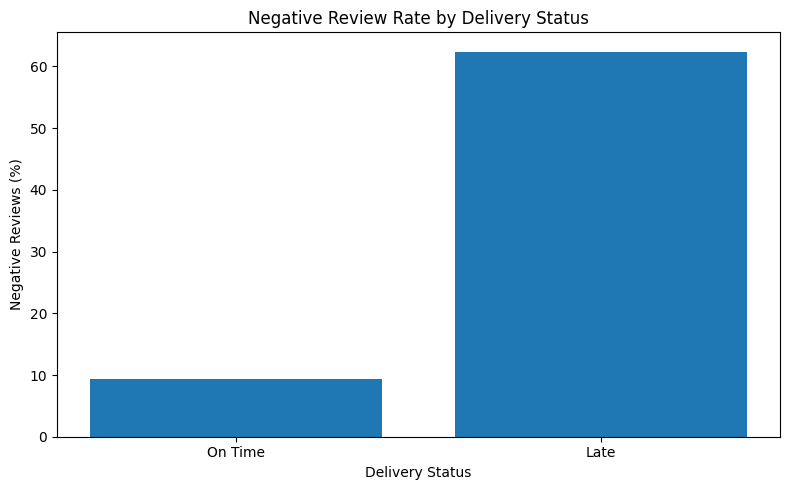

In [87]:
plot_data = (
    delivery_satisfaction
    .set_index("delivery_status")
    .loc[["On Time", "Late"]]
    .reset_index()
)

plt.figure(figsize=(8, 5))

plt.bar(
    plot_data["delivery_status"],
    plot_data["negative_review_percentage"]
)

plt.title("Negative Review Rate by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Negative Reviews (%)")

plt.tight_layout()
plt.show()

Review Distribution and Category Satisfaction

In [88]:
# Delivered-order reviews only
delivered_reviews = (
    delivered_orders[["order_id"]]
    .merge(
        reviews[["order_id", "review_score"]],
        on="order_id",
        how="inner"
    )
)

# Review distribution for delivered orders only
review_distribution = (
    delivered_reviews["review_score"]
    .value_counts()
    .sort_index()
    .rename_axis("review_score")
    .reset_index(name="reviews")
)

review_distribution["percentage"] = (
    review_distribution["reviews"]
    / review_distribution["reviews"].sum()
    * 100
)

review_distribution

,review_score,reviews,percentage
0,1,9406,9.76
1,2,2941,3.05
2,3,7961,8.26
3,4,18987,19.70
4,5,57066,59.22


In [89]:
overall_satisfaction = {
    "total_reviews": len(delivered_reviews),
    "avg_review_score": delivered_reviews["review_score"].mean(),
    "positive_percentage":
        (delivered_reviews["review_score"] >= 4).mean() * 100,
    "negative_percentage":
        (delivered_reviews["review_score"] <= 2).mean() * 100
}

overall_satisfaction

{'total_reviews': 96361,
 'avg_review_score': np.float64(4.155716524320005),
 'positive_percentage': np.float64(78.92508379946244),
 'negative_percentage': np.float64(12.813275080167289)}

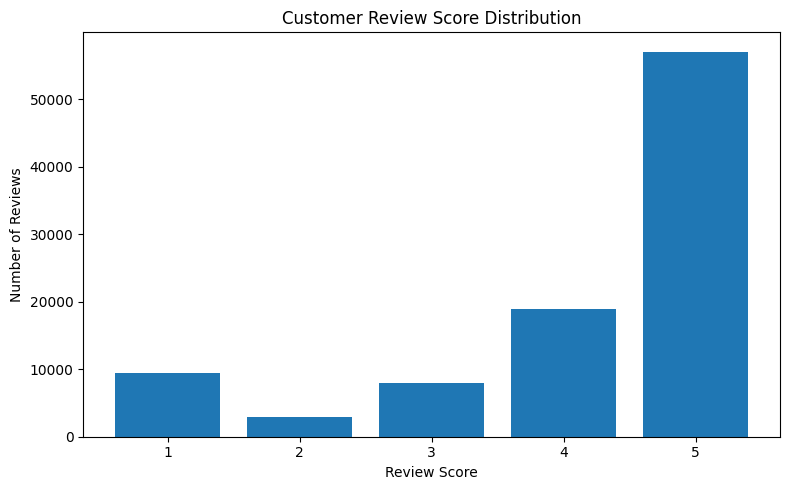

In [90]:
plt.figure(figsize=(8, 5))

plt.bar(
    review_distribution["review_score"].astype(str),
    review_distribution["reviews"]
)

plt.title("Customer Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()

In [91]:
order_categories = (
    category_sales_data[
        ["order_id", "category"]
    ]
    .drop_duplicates()
)

In [92]:
category_review_data = (
    order_categories
    .merge(
        reviews[["order_id", "review_score"]],
        on="order_id",
        how="inner"
    )
)

In [93]:
category_satisfaction = (
    category_review_data
    .groupby("category")
    .agg(
        total_reviews=("review_score", "count"),
        avg_review_score=("review_score", "mean"),
        positive_percentage=(
            "review_score",
            lambda x: (x >= 4).mean() * 100
        ),
        negative_percentage=(
            "review_score",
            lambda x: (x <= 2).mean() * 100
        )
    )
    .reset_index()
)

category_satisfaction = category_satisfaction[
    category_satisfaction["total_reviews"] >= 100
]

category_satisfaction[
    [
        "avg_review_score",
        "positive_percentage",
        "negative_percentage"
    ]
] = category_satisfaction[
    [
        "avg_review_score",
        "positive_percentage",
        "negative_percentage"
    ]
].round(2)

In [94]:
category_satisfaction.sort_values(
    "avg_review_score",
    ascending=False
).head(10)

,category,total_reviews,avg_review_score,positive_percentage,negative_percentage
9,books_general_interest,492,4.53,90.24,6.30
38,food_drink,223,4.45,85.20,4.04
11,books_technical,257,4.43,87.16,9.34
54,luggage_accessories,1015,4.37,85.02,8.18
37,food,437,4.33,84.90,10.07
69,stationery,2258,4.29,83.39,10.10
62,pet_shop,1682,4.27,82.22,10.64
32,fashion_shoes,234,4.27,81.20,11.11
66,small_appliances,608,4.26,82.73,11.51
61,perfumery,3090,4.26,81.33,11.88


In [95]:
category_satisfaction.sort_values(
    "avg_review_score"
).head(10)

,category,total_reviews,avg_review_score,positive_percentage,negative_percentage
58,office_furniture,1249,3.64,63.49,22.02
31,fashion_male_clothing,105,3.82,70.48,22.86
5,audio,346,3.83,68.50,21.97
48,home_confort,393,3.88,68.19,18.83
20,construction_tools_safety,158,3.97,75.32,17.09
35,fixed_telephony,210,3.97,74.76,16.67
49,home_construction,482,3.99,74.90,17.22
8,bed_bath_table,9295,4.00,73.93,16.09
0,Unknown,1390,4.01,76.47,17.41
34,fashion_underwear_beach,116,4.01,76.72,16.38


Category Revenue vs. Customer Satisfaction

In [96]:
category_performance = (
    category_sales[
        [
            "category",
            "orders",
            "products_sold",
            "revenue",
            "revenue_percentage"
        ]
    ]
    .merge(
        category_satisfaction[
            [
                "category",
                "total_reviews",
                "avg_review_score",
                "negative_percentage"
            ]
        ],
        on="category",
        how="left"
    )
)

category_performance = category_performance[
    category_performance["total_reviews"] >= 100
]

category_performance.sort_values(
    "revenue",
    ascending=False
).head(15)

,category,orders,products_sold,revenue,revenue_percentage,total_reviews,avg_review_score,negative_percentage
0,health_beauty,8647,9465,"1,233,131.72",9.33,"8,654.00",4.23,11.43
1,watches_gifts,5495,5859,"1,166,176.98",8.82,"5,464.00",4.12,13.69
2,bed_bath_table,9272,10953,"1,023,434.76",7.74,"9,295.00",4.00,16.09
3,sports_leisure,7530,8431,"954,852.55",7.22,"7,537.00",4.23,11.36
4,computers_accessories,6530,7644,"888,724.61",6.72,"6,549.00",4.08,14.55
5,furniture_decor,6307,8160,"711,927.69",5.38,"6,317.00",4.05,15.40
6,housewares,5743,6795,"615,628.69",4.66,"5,730.00",4.19,11.78
7,cool_stuff,3559,3718,"610,204.10",4.62,"3,540.00",4.22,11.30
8,auto,3810,4140,"578,966.65",4.38,"3,808.00",4.15,13.00
9,toys,3804,4030,"471,286.48",3.56,"3,782.00",4.24,11.40


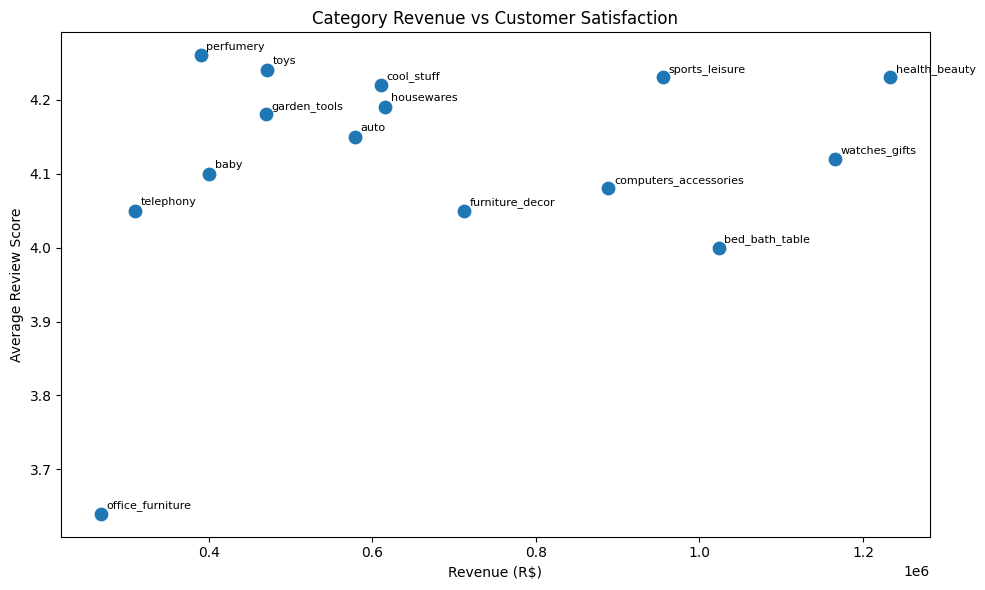

In [97]:
top15 = (
    category_performance
    .sort_values("revenue", ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 6))

plt.scatter(
    top15["revenue"],
    top15["avg_review_score"],
    s=80
)

for _, row in top15.iterrows():
    plt.annotate(
        row["category"],
        (row["revenue"], row["avg_review_score"]),
        fontsize=8,
        xytext=(4, 4),
        textcoords="offset points"
    )

plt.title("Category Revenue vs Customer Satisfaction")
plt.xlabel("Revenue (R$)")
plt.ylabel("Average Review Score")

plt.tight_layout()
plt.show()

In [98]:
processed_path = (
    "/content/drive/MyDrive/"
    "Olist_Ecommerce_Project/data/processed/"
)

In [99]:
import os

os.makedirs(processed_path, exist_ok=True)

In [100]:
monthly_sales.to_csv(
    processed_path + "monthly_sales.csv",
    index=False
)

category_sales.to_csv(
    processed_path + "category_sales.csv",
    index=False
)

customer_summary.to_csv(
    processed_path + "customer_summary.csv",
    index=False
)

customer_value.to_csv(
    processed_path + "customer_value.csv",
    index=False
)

delivery_satisfaction.to_csv(
    processed_path + "delivery_satisfaction.csv",
    index=False
)

review_distribution.to_csv(
    processed_path + "review_distribution.csv",
    index=False
)

category_performance.to_csv(
    processed_path + "category_performance.csv",
    index=False
)

print("Processed files saved successfully.")

Processed files saved successfully.


In [101]:
import os

os.listdir(processed_path)

['powerbi_orders.csv',
 'powerbi_sales.csv',
 'powerbi_reviews.csv',
 'olist-ecommerce-analytics.zip',
 'monthly_sales.csv',
 'category_sales.csv',
 'review_distribution.csv',
 'category_performance.csv',
 'customer_value.csv',
 'delivery_satisfaction.csv',
 'customer_summary.csv']

Order level table

In [102]:
# Average review score per order
review_by_order = (
    reviews.groupby("order_id")
    .agg(
        review_score=("review_score", "mean"),
        review_count=("review_score", "count")
    )
    .reset_index()
)

# Order-level dataset
powerbi_orders = (
    delivered_orders
    .merge(
        customers[
            ["customer_id", "customer_unique_id",
             "customer_city", "customer_state"]
        ],
        on="customer_id",
        how="left"
    )
    .merge(
        review_by_order,
        on="order_id",
        how="left"
    )
)

powerbi_orders["purchase_month"] = (
    powerbi_orders["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

powerbi_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,valid_delivery_days,delivery_status,carrier_before_purchase,customer_unique_id,customer_city,customer_state,review_score,review_count,purchase_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.44,8.44,On Time,False,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,4.00,1.00,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.78,13.78,On Time,False,af07308b275d755c9edb36a90c618231,barreiras,BA,4.00,1.00,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.39,9.39,On Time,False,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,5.00,1.00,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.21,13.21,On Time,False,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,5.00,1.00,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.87,2.87,On Time,False,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,5.00,1.00,2018-02


In [103]:
powerbi_sales = (
    sales
    .merge(
        customers[
            ["customer_id", "customer_unique_id",
             "customer_state"]
        ],
        on="customer_id",
        how="left"
    )
    .merge(
        products[
            ["product_id", "product_category_name"]
        ],
        on="product_id",
        how="left"
    )
    .merge(
        category_translation,
        on="product_category_name",
        how="left"
    )
    .merge(
        sellers[
            ["seller_id", "seller_city", "seller_state"]
        ],
        on="seller_id",
        how="left"
    )
)

powerbi_sales["category"] = (
    powerbi_sales["product_category_name_english"]
    .fillna(powerbi_sales["product_category_name"])
    .fillna("Unknown")
)

powerbi_sales["purchase_month"] = (
    powerbi_sales["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

powerbi_sales["total_order_item_value"] = (
    powerbi_sales["price"] +
    powerbi_sales["freight_value"]
)

powerbi_sales.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,valid_delivery_days,delivery_status,carrier_before_purchase,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,purchase_month,customer_unique_id,customer_state,product_category_name,product_category_name_english,seller_city,seller_state,category,total_order_item_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.44,8.44,On Time,False,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,2017-10,7c396fd4830fd04220f754e42b4e5bff,SP,utilidades_domesticas,housewares,maua,SP,housewares,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.78,13.78,On Time,False,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,2018-07,af07308b275d755c9edb36a90c618231,BA,perfumaria,perfumery,belo horizonte,SP,perfumery,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.39,9.39,On Time,False,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,2018-08,3a653a41f6f9fc3d2a113cf8398680e8,GO,automotivo,auto,guariba,SP,auto,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.21,13.21,On Time,False,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,2017-11,7c142cf63193a1473d2e66489a9ae977,RN,pet_shop,pet_shop,belo horizonte,MG,pet_shop,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.87,2.87,On Time,False,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,2018-02,72632f0f9dd73dfee390c9b22eb56dd6,SP,papelaria,stationery,mogi das cruzes,SP,stationery,28.62


In [104]:
powerbi_orders.to_csv(
    processed_path + "powerbi_orders.csv",
    index=False
)

powerbi_sales.to_csv(
    processed_path + "powerbi_sales.csv",
    index=False
)

print("Power BI files saved.")

Power BI files saved.


In [105]:
print("Orders:", powerbi_orders.shape)
print("Sales:", powerbi_sales.shape)

Orders: (96478, 18)
Sales: (110197, 27)


In [106]:
powerbi_reviews = (
    reviews[
        ["review_id", "order_id", "review_score"]
    ]
    .merge(
        orders[
            [
                "order_id",
                "order_status",
                "order_purchase_timestamp",
                "delivery_status",
                "valid_delivery_days",
                "customer_id"
            ]
        ],
        on="order_id",
        how="inner"
    )
)

powerbi_reviews = powerbi_reviews[
    powerbi_reviews["order_status"] == "delivered"
].copy()

powerbi_reviews = powerbi_reviews.merge(
    customers[
        ["customer_id", "customer_state"]
    ],
    on="customer_id",
    how="left"
)

powerbi_reviews["purchase_month"] = (
    powerbi_reviews["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

powerbi_reviews.to_csv(
    processed_path + "powerbi_reviews.csv",
    index=False
)

print(powerbi_reviews.shape)

(96361, 10)
